In [1]:
!pip install nnunetv2 nibabel SimpleITK

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 205.6/205.6 kB 7.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 9.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.7/73.7 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 81.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 109.9 MB/s eta 0:00:00

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os

os.environ['nnUNet_raw'] = '/content/nnUNet_raw'
os.environ['nnUNet_preprocessed'] = '/content/nnUNet_preprocessed'
os.environ['nnUNet_results'] = '/content/nnUNet_results'

!mkdir -p /content/nnUNet_results
!mkdir -p /content/test/imagesTs
!mkdir -p /content/test/preds

In [6]:
!cp -r /content/drive/MyDrive/Dataset112_ToothFairy2 \
      /content/nnUNet_results/

In [7]:
import shutil

source_folder = "/content/drive/MyDrive/test_scans"
target_folder = "/content/test/imagesTs"

# Clear previous files
!rm -rf /content/test/imagesTs/*
os.makedirs(target_folder, exist_ok=True)

files = sorted(os.listdir(source_folder))[:3]

for i, f in enumerate(files):
    src = os.path.join(source_folder, f)
    dst = os.path.join(target_folder, f"case_{i:04d}_0000.nii.gz")
    shutil.copy(src, dst)

print("Copied 3 scans:", files)

Copied 3 scans: ['1001470164_20180114.nii.gz', '1001470284_20180115.nii.gz', '1001484858_20150118.nii.gz']


In [8]:
import SimpleITK as sitk

for f in os.listdir(target_folder):
    path = os.path.join(target_folder, f)

    img = sitk.ReadImage(path)

    new_path = path.replace(".nii.gz", ".mha")
    sitk.WriteImage(img, new_path)

    os.remove(path)

print("Converted to MHA")

Converted to MHA


In [9]:
!nnUNetv2_predict \
-i /content/test/imagesTs \
-o /content/test/preds \
-d 112 \
-c 3d_fullres \
-f 0 \
-chk checkpoint_best.pth


#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

There are 3 cases in the source folder
I am processing 0 out of 1 (max process ID is 0, we start counting with 0!)
There are 3 cases that I would like to predict

Predicting case_0000:
perform_everything_on_device: True
100% 252/252 [04:48<00:00,  1.15s/it]
sending off prediction to background worker for resampling and export
done with case_0000

Predicting case_0001:
perform_everything_on_device: True
100% 252/252 [04:54<00:00,  1.17s/it]
sending off prediction to background worker for resampling and export
done with case_0001

Predicting case_0002:
perform_everything_on_device: True
100% 

In [30]:
def classify_apical(apical):
    if apical >= 4:
        return "Green"
    elif apical >= 2:
        return "Yellow"
    else:
        return "Red"


def classify_buccal(buccal):
    if buccal >= 2:
        return "Green"
    elif buccal >= 1:
        return "Yellow"
    else:
        return "Red"


def classify_septum(septum):
    if septum >= 3:
        return "Green"
    elif septum >= 2:
        return "Yellow"
    else:
        return "Red"


def classify_ridge(ridge):
    if ridge >= 7:
        return "Green"
    elif ridge >= 5:
        return "Yellow"
    else:
        return "Red"


def classify_lesion(lesion):
    return "Red" if lesion else "Green"


def final_sac_classification(colors):

    if "Red" in colors:
        return "Complex"
    elif "Yellow" in colors:
        return "Advanced"
    else:
        return "Simple"

In [31]:
import numpy as np
import scipy.ndimage as ndi

voxel_mm = 0.3

def compute_sac(pred, img):

    z = pred.shape[0] // 2

    # Missing tooth detection
    teeth = (pred[z] == 1)
    labeled, num = ndi.label(teeth)

    centroids = []
    for i in range(1, num + 1):
        coords = np.argwhere(labeled == i)
        centroids.append(coords.mean(axis=0))

    centroids = np.array(centroids)
    centroids = centroids[np.argsort(centroids[:, 1])]

    distances = np.linalg.norm(np.diff(centroids, axis=0), axis=1)
    gap_idx = np.argmax(distances)

    missing = (centroids[gap_idx] + centroids[gap_idx + 1]) / 2
    x, y = int(missing[0]), int(missing[1])


    # Local extraction
    window = 20

    local_img = img[z][
        x-window:x+window,
        y-window:y+window
    ]

    bone = local_img > 200

    teeth_local = (pred[z] == 1)[
        x-window:x+window,
        y-window:y+window
    ]

    # expand teeth region slightly
    teeth_zone = ndi.binary_dilation(teeth_local, iterations=4)

    # restrict bone near teeth
    bone = bone & teeth_zone

    # 1. APICAL BONE
    col = bone[:, window]
    idx = np.where(col > 0)[0]

    apical_px = idx[-1] - window if len(idx) > 0 else 0
    apical_mm = apical_px * voxel_mm

    # 2. BUCCAL THICKNESS
    front = bone[window, :window]
    idx = np.where(front > 0)[0]

    buccal_px = len(idx) if len(idx) > 0 else 0
    buccal_mm = buccal_px * voxel_mm

    # clamp unrealistic values
    if buccal_mm > 5:
        buccal_mm = 5

    # 3. SEPTUM WIDTH
    septum_mm = 0
    is_molar = False

    labeled_teeth, num_teeth = ndi.label(teeth_local)

    if num_teeth >= 2:
        is_molar = True
        centers = []

        for i in range(1, num_teeth + 1):
            coords = np.argwhere(labeled_teeth == i)
            centers.append(coords.mean(axis=0))

        centers = np.array(centers)

        dists = []
        for i in range(len(centers)):
            for j in range(i + 1, len(centers)):
                dists.append(np.linalg.norm(centers[i] - centers[j]))

        if len(dists) > 0:
            septum_mm = min(dists) * voxel_mm

    # 4. RIDGE WIDTH
    row = bone[window]
    idx = np.where(row > 0)[0]

    ridge_px = idx[-1] - idx[0] if len(idx) > 0 else 0
    ridge_mm = ridge_px * voxel_mm

    # clamp unrealistic values
    if ridge_mm > 10:
        ridge_mm = 10

    # 5. LESION
    low_density = local_img < 100
    candidate = low_density & ndi.binary_erosion(bone, iterations=1)

    labeled, num = ndi.label(candidate)
    sizes = [np.sum(labeled == i) for i in range(1, num + 1)]

    lesion = any(s > 80 for s in sizes)

    # classify each factor
    apical_c = classify_apical(apical_mm)
    buccal_c = classify_buccal(buccal_mm)
    ridge_c = classify_ridge(ridge_mm)
    lesion_c = classify_lesion(lesion)

    if is_molar:
        septum_c = classify_septum(septum_mm)
    else:
        septum_c = "N/A"

    # collect valid colors
    colors = [apical_c, buccal_c, ridge_c, lesion_c]

    if is_molar:
      colors.append(septum_c)

    # final classification
    cls = final_sac_classification(colors)

    return {
    "Apical Bone (mm)": round(float(apical_mm), 2),
    "Apical Status": apical_c,

    "Buccal Thickness (mm)": round(float(buccal_mm), 2),
    "Buccal Status": buccal_c,

    "Ridge Width (mm)": round(float(ridge_mm), 2),
    "Ridge Status": ridge_c,

    "Septum Width (mm)": round(float(septum_mm), 2) if is_molar else "N/A",
    "Septum Status": septum_c,

    "Lesion": lesion,
    "Lesion Status": lesion_c,

    "Final Classification": cls
}

In [32]:
results = {}

for f in os.listdir("/content/test/preds"):
    if not f.endswith(".mha"):
        continue

    pred = sitk.GetArrayFromImage(
        sitk.ReadImage(f"/content/test/preds/{f}")
    )

    img = sitk.GetArrayFromImage(
        sitk.ReadImage(f"/content/test/imagesTs/{f.replace('.mha','_0000.mha')}")
    )

    res = compute_sac(pred, img)
    results[f] = res

results

{'case_0002.mha': {'Apical Bone (mm)': 5.7,
  'Apical Status': 'Green',
  'Buccal Thickness (mm)': 0.6,
  'Buccal Status': 'Red',
  'Ridge Width (mm)': 6.0,
  'Ridge Status': 'Yellow',
  'Septum Width (mm)': 6.73,
  'Septum Status': 'Green',
  'Lesion': False,
  'Lesion Status': 'Green',
  'Final Classification': 'Complex'},
 'case_0001.mha': {'Apical Bone (mm)': 1.8,
  'Apical Status': 'Red',
  'Buccal Thickness (mm)': 5.0,
  'Buccal Status': 'Green',
  'Ridge Width (mm)': 10.0,
  'Ridge Status': 'Green',
  'Septum Width (mm)': 6.6,
  'Septum Status': 'Green',
  'Lesion': False,
  'Lesion Status': 'Green',
  'Final Classification': 'Complex'},
 'case_0000.mha': {'Apical Bone (mm)': 5.7,
  'Apical Status': 'Green',
  'Buccal Thickness (mm)': 3.3,
  'Buccal Status': 'Green',
  'Ridge Width (mm)': 8.1,
  'Ridge Status': 'Green',
  'Septum Width (mm)': 7.85,
  'Septum Status': 'Green',
  'Lesion': False,
  'Lesion Status': 'Green',
  'Final Classification': 'Simple'}}

In [27]:
import numpy as np
import scipy.ndimage as ndi

def get_missing_tooth_location(pred):
    z_all = pred.shape[0]
    teeth_vol = (pred == 1)

    # best slice = most teeth
    z = np.argmax(teeth_vol.sum(axis=(1,2)))

    teeth = teeth_vol[z]
    labeled, num = ndi.label(teeth)

    centroids = []
    for i in range(1, num + 1):
        coords = np.argwhere(labeled == i)
        centroids.append(coords.mean(axis=0))

    centroids = np.array(centroids)
    centroids = centroids[np.argsort(centroids[:, 1])]

    distances = np.linalg.norm(np.diff(centroids, axis=0), axis=1)
    gap_idx = np.argmax(distances)

    missing = (centroids[gap_idx] + centroids[gap_idx + 1]) / 2

    x, y = int(missing[0]), int(missing[1])

    return z, x, y

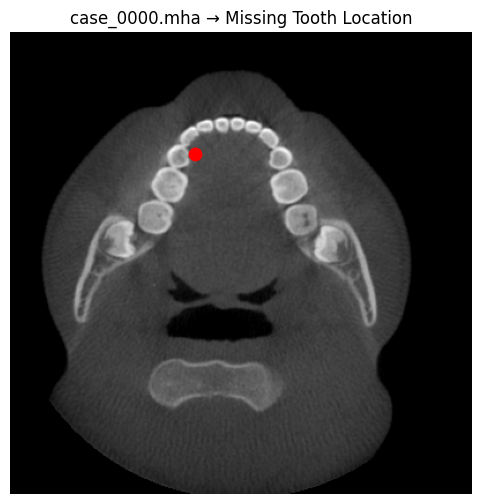

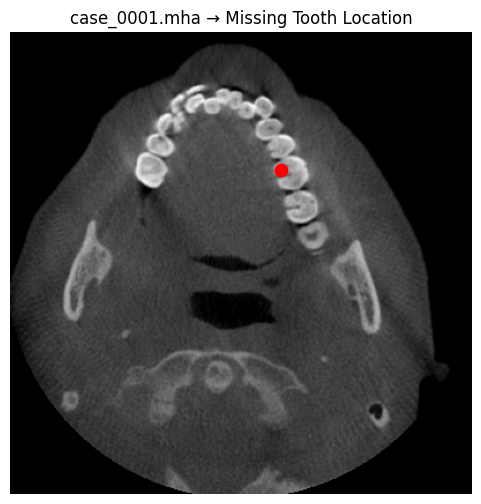

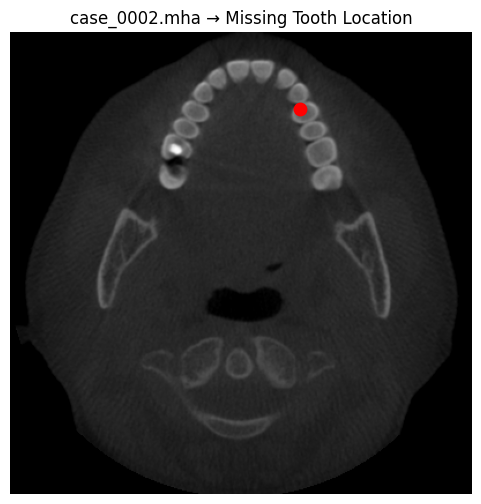

In [33]:
import matplotlib.pyplot as plt
import SimpleITK as sitk
import os

for f in sorted(os.listdir("/content/test/preds")):

    if not f.endswith(".mha"):
        continue

    # Load prediction
    pred = sitk.GetArrayFromImage(
        sitk.ReadImage(f"/content/test/preds/{f}")
    )

    # Load image
    img = sitk.GetArrayFromImage(
        sitk.ReadImage(f"/content/test/imagesTs/{f.replace('.mha','_0000.mha')}")
    )

    # Get missing tooth location
    z, x, y = get_missing_tooth_location(pred)

    # Plot
    plt.figure(figsize=(6,6))
    plt.imshow(img[z], cmap='gray')

    plt.scatter(y, x, c='red', s=80)

    plt.title(f"{f} → Missing Tooth Location")
    plt.axis('off')
    plt.show()